In [258]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [259]:
full = pd.read_csv('../dataset/final_eda.csv')

In [260]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
# t_received에 따라서 순서대로 instance_id가 1,2,3,... 으로 배정
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [261]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [262]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [263]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [264]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [265]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'), # 같은 t_receive(instance_id), customer_id, offer_id를 몇번 완료했는지 카운트
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [266]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [267]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [268]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

print("\n✓ 중복 매핑 체크 통과 \n")

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)

✓ 중복 매핑 체크 통과 

[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [269]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna()
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna()
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
)

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [270]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [271]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,True,True,False,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,True,True,False,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,True,True,True,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,True,True,True,NaN


In [272]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [273]:
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [274]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,True,False,False,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,True,False,False,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,True,True,False,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,True,True,False,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,True,False,False,NaN


In [275]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'gap_first_view_to_first_complete'],
      dtype='str')

In [276]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [277]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [278]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [279]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed', 'gap_to_first_view', 'gap_to_first_complete', 'gap_first_view_to_first_complete']].mean()

,is_viewed,is_completed,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [280]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN


In [281]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']].copy()

In [282]:
funnel_instance.to_csv('../dataset/funnel_instance.csv', index=False)

### 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [283]:
full = pd.read_csv('../dataset/final_eda.csv')
funnel = pd.read_csv('../dataset/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [284]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [285]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [286]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [287]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


### 여기부터 내 코드

In [288]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [289]:
# === [품질 체크 4] 유효기간(duration) 내에 완료되지 않은 이상치 여부 ===
n_over_expire = funnel[funnel['t_expire']<funnel['t_completed']] # 유효기간 내에 완료되지 않은 이상치 확인
print(f"유효기간 내에 완료되지 않은 이상치 개수 (0이어야 정상): {len(n_over_expire)}")

유효기간 내에 완료되지 않은 이상치 개수 (0이어야 정상): 0


In [290]:
df = funnel.copy()
df['is_viewed'] = df['is_viewed'].astype(int)
df['is_completed'] = df['is_completed'].astype(int)
df['completed_without_prior_view'] = df['completed_without_prior_view'].astype(int)
df.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [291]:
# completed with prior view 컬럼 생성
mask = ((df['is_viewed']) & (df['is_completed']) & (df['t_viewed'] < df['t_completed']))
df['completed_with_prior_view'] = np.where(mask, 1, 0)

In [292]:
df.tail()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,1,1,0,30.0,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,1
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,1,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,1,1,1,NaN,5.0,5.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76276,ffff82501cea40309d5fdd7edcca4a07,fafdcd668e3743c1bb461111dcafc2a4,0,discount,1,10.0,240.0,6.0,6.0,1.0,0.0,60.0,60.0,1.0,0.0,6.0,60.0,1,1,0,54.0,2.0,10.0,1.0,1.0,1.0,1.0,4.0,F,40대,5-7.5만,2016,11,2016-11,1


In [293]:
df[(df['completed_with_prior_view']==0) & (df['completed_without_prior_view']==0)]

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,1,0,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,Unknown,누락,누락,2018,4,2018-04,0
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,1,0,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,Unknown,누락,누락,2018,4,2018-04,0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,1,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,O,40대,5-7.5만,2018,1,2018-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76264,fff8957ea8b240a6b5e634b6ee8eafcf,3f207df678b143eea3cee63160fa8bed,504,informational,1,4.0,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,60대 이상,5-7.5만,2018,2,2018-02,0
76265,fff8957ea8b240a6b5e634b6ee8eafcf,4d5c57ea9a6940dd891ad53e9dbe8da0,576,bogo,1,5.0,696.0,660.0,660.0,1.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,1,0,0,NaN,10.0,10.0,1.0,1.0,1.0,1.0,4.0,M,60대 이상,5-7.5만,2018,2,2018-02,0
76266,fff8957ea8b240a6b5e634b6ee8eafcf,fafdcd668e3743c1bb461111dcafc2a4,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,60대 이상,5-7.5만,2018,2,2018-02,0
76267,fffad4f4828548d1b5583907f2e9906b,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,168.0,168.0,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5만 미만,2017,1,2017-01,0


In [294]:
df[df['t_viewed']==df['t_completed']]

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
86,0091d2b6a5ea4defaa8393e4e816db60,4d5c57ea9a6940dd891ad53e9dbe8da0,0,bogo,1,5.0,120.0,6.0,6.0,1.0,0.0,6.0,6.0,1.0,0.0,6.0,6.0,1,1,0,NaN,10.0,10.0,1.0,1.0,1.0,1.0,4.0,F,60대 이상,7.5-10만,2016,6,2016-06,0
88,0091d2b6a5ea4defaa8393e4e816db60,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,408.0,408.0,1.0,0.0,408.0,408.0,1.0,0.0,0.0,0.0,1,1,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,F,60대 이상,7.5-10만,2016,6,2016-06,0
160,00c20a9202d5475190b31a24de6fb06d,4d5c57ea9a6940dd891ad53e9dbe8da0,576,bogo,1,5.0,696.0,576.0,576.0,1.0,0.0,576.0,576.0,1.0,0.0,0.0,0.0,1,1,0,NaN,10.0,10.0,1.0,1.0,1.0,1.0,4.0,O,50대,7.5-10만,2016,3,2016-03,0
179,00c6035df45840038a72766c6d27a0db,ae264e3637204a6fb9bb56bc8210ddfd,168,bogo,1,7.0,336.0,180.0,180.0,1.0,0.0,180.0,180.0,1.0,0.0,12.0,12.0,1,1,0,NaN,10.0,10.0,0.0,1.0,1.0,1.0,3.0,M,40대,7.5-10만,2017,2,2017-02,0
181,00c91f31f5f74e769fa7a359b63e1a9f,2298d6c36e964ae4a3e7e9706d1fb8c2,336,discount,1,7.0,504.0,342.0,342.0,1.0,0.0,342.0,342.0,1.0,0.0,6.0,6.0,1,1,0,NaN,3.0,7.0,1.0,1.0,1.0,1.0,4.0,F,20대,5만 미만,2016,11,2016-11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76137,ff932c6f8bb641bd816955337d153676,fafdcd668e3743c1bb461111dcafc2a4,408,discount,1,10.0,648.0,408.0,408.0,1.0,0.0,408.0,408.0,1.0,0.0,0.0,0.0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,60대 이상,7.5-10만,2015,9,2015-09,0
76186,ffb7fc8ad0594248a49e210ff0217c2d,f19421c1d4aa40978ebb69ca19b0e20d,504,bogo,2,5.0,624.0,534.0,534.0,1.0,0.0,534.0,534.0,1.0,0.0,30.0,30.0,1,1,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,F,50대,10만 이상,2015,9,2015-09,0
76252,fff29fb549084123bd046dbc5ceb4faa,fafdcd668e3743c1bb461111dcafc2a4,168,discount,1,10.0,408.0,168.0,168.0,1.0,0.0,168.0,168.0,1.0,0.0,0.0,0.0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,F,50대,7.5-10만,2017,8,2017-08,0
76258,fff3ba4757bd42088c044ca26d73817a,fafdcd668e3743c1bb461111dcafc2a4,0,discount,1,10.0,240.0,6.0,6.0,1.0,0.0,6.0,6.0,1.0,0.0,6.0,6.0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,F,60대 이상,7.5-10만,2015,9,2015-09,0


complete_count : 같은 t_receive(instance_id), customer_id, offer_id를 몇번 완료했는지 카운트

offer_type, duration, view_count, complete_count(instance_id를 몇 번 완료헸는지), gap_to_view, gap_to_complete, gap_view_to_complete, is_viewed, is_completed, completed_with_prior_view, completed_without_prior_view, reward, difficulty, ch_web, ch_email, ch_mobile, ch_social, channel_count

In [295]:
# 채널별, 채널수별 gap_to_view만 보는 것 : 전체 데이터 사용 -> 열람까지 걸리는 시간
channel_df_rate = df.groupby(['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    view_rate = ('is_viewed', 'mean'),  #열람률
    count = ('gender', 'size')
).reset_index()
channel_df_rate.sort_values(by=['avg_gap_to_view'], ascending=[True])  # 채널수가 많을수록, 웹보다는 소셜의 도달 시간이 빠르다 채널을 많이 활용할 수록 도달시간이 빨라지고 도달률도 높아진다

,ch_web,ch_email,ch_mobile,ch_social,channel_count,avg_gap_to_view,view_rate,count
3,1.0,1.0,1.0,1.0,4.0,19.956907,0.957016,30407
0,0.0,1.0,1.0,1.0,3.0,23.922825,0.839749,15276
2,1.0,1.0,1.0,0.0,3.0,31.155252,0.522856,22926
1,1.0,1.0,0.0,0.0,2.0,44.194570,0.345853,7668


In [296]:
# 채널수와 시간에 관한 통계검정
# Kruskal-Wallis 검정 수행 (stats.kruskal) 함수 (사후검정 포함)
from scipy import stats
import scikit_posthocs as sp

def kruskal(group_a, group_b, group_c):
    h_stat, kw_p = stats.kruskal(group_a, group_b, group_c)
    print(f"  H 통계량: {h_stat:.4f}")
    print(f"  p-value: {kw_p:.4f}")

    # η²_H 효과크기 계산
    # 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
    k = 3
    N = len(group_a) + len(group_b) + len(group_c)
    eta_sq_h = (h_stat - k + 1) / (N - k)

    if h_stat is not None:
        print(f"  H 통계량: {h_stat:.4f}")
        print(f"  p-value: {kw_p:.4f}")

    if eta_sq_h is not None:
        size_eta = '작은' if eta_sq_h < 0.06 else '중간' if eta_sq_h < 0.14 else '큰'
        print(f"\n  [효과크기] η²_H = {eta_sq_h:.4f} ({size_eta} 효과)")

    if kw_p is not None:
        verdict = 'H₀ 기각: 유의한 차이가 있습니다' if kw_p < 0.05 else 'H₀ 기각 실패: 유의한 차이가 없습니다'
        print(f"  판정: {verdict}")    


    # Kruskal-Wallis에 대한 사후 검정 : Dunn Test
    if kw_p is not None and kw_p < 0.05:
        print(f"\nDunn 사후검정 (Holm 보정)")
        print("=" * 60)
        data_list = [group_a, group_b, group_c]

        # Dunn's Test 수행 (p_adjust는 다중 비교 보정을 위해 'holm' 혹은 'bonferroni' 사용) --> holm이 검정력이 더 좋은 경향!
        # 결과는 행렬 형태로 반환
        dunn = sp.posthoc_dunn(data_list, p_adjust='holm')

        # 인덱스와 컬럼명을 보기 좋게 변경
        dunn.columns = ['2개', '3개', '4개']
        dunn.index = ['2개', '3개', '4개']

        display(dunn.round(4))

        # 중앙값 계산
        # 시간(Gap) 데이터는 이상치가 많기 때문에 비모수 검정 결과의 방향성을 설명할 땐 평균보다 중앙값이 더 적절함
        group_names = dunn.columns.tolist() # ['2개', '3개', '4개']
        medians = {name: np.median(data) for name, data in zip(group_names, data_list)}

        # 쌍별 비교 및 방향성 해석
        for i in range(len(group_names)):
            for j in range(i + 1, len(group_names)):
                g1, g2 = group_names[i], group_names[j]
                data1, data2 = data_list[i], data_list[j] # 실제 데이터 추출

                p_val = dunn.loc[g1, g2]
                sig = "유의한 차이 있음" if p_val < 0.05 else "차이 없음"

                # 쌍별 효과 크기(Rank-Biserial r) 계산 ──
                u_stat, _ = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                n1, n2 = len(data1), len(data2)
                r_val = abs(1 - (2 * u_stat) / (n1 * n2)) # 절대값으로 크기 표현
                
                # 효과 크기 해석
                r_size = '작음' if r_val < 0.3 else '중간' if r_val < 0.5 else '큼'

                m1, m2 = medians[g1], medians[g2]
                
                # 시간(Gap) 데이터는 '낮을수록' 빠른 것이므로 해석에 주의!
                if m1 > m2:
                    direction = f"{g2}({m2:.1f}h)가 {g1}({m1:.1f}h)보다 더 빠릅니다"
                elif m1 < m2:
                    direction = f"{g1}({m1:.1f}h)가 {g2}({m2:.1f}h)보다 더 빠릅니다"
                else:
                    direction = "두 집단의 반응 속도가 동일합니다"

                print(f"  [{g1} vs {g2}] {sig} (p={p_val:.4f})")
                print(f"    → 효과 크기(r): {r_val:.4f} ({r_size} 수준)")
                print(f"    → {direction}")
                print("-" * 30)

In [297]:
# 채널수 -> 열람까지 걸리는 시간이 빠른가? 에 대한 통계 검정: Kruskal-Wallis 검정

print(f"\nKruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_view'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_view'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_view'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이
  H 통계량: 1837.5230
  p-value: 0.0000
  H 통계량: 1837.5230
  p-value: 0.0000

  [효과크기] η²_H = 0.0325 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.2580 (작음 수준)
    → 3개(18.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3986 (중간 수준)
    → 4개(12.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.1551 (작음 수준)
    → 4개(12.0h)가 3개(18.0h)보다 더 빠릅니다
------------------------------


In [ ]:
# 채널 활용 유무에 따른 열람까지 걸리는 시간 확인
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

for ch in channels:
    channel_df_rate = df.groupby(ch).agg( 
        avg_gap_to_view = ('gap_to_view', 'mean'),
        view_rate = ('is_viewed', 'mean'),  
        count = ('gender', 'size')
    ).reset_index()
    channel_df_rate.sort_values(by=['avg_gap_to_view'], ascending=[True]) 
    display(channel_df_rate) # 모바일과 소셜의 활용 유무가 도달시간에 영향을 많이 미친다 (열람률에 대해선 아래 교차표 해석 이용)

,ch_web,avg_gap_to_view,view_rate,count
0,0.0,23.922825,0.839749,15276
1,1.0,24.495485,0.717021,61001


,ch_email,avg_gap_to_view,view_rate,count
0,1.0,24.36562,0.7416,76277


,ch_mobile,avg_gap_to_view,view_rate,count
0,0.0,44.194570,0.345853,7668
1,1.0,23.390262,0.785830,68609


,ch_social,avg_gap_to_view,view_rate,count
0,0.0,33.517453,0.478493,30594
1,1.0,21.170292,0.917803,45683


In [299]:
# 채널 활용 유무에 관한 통계검정
# Mann-Whitney U검정 함수
def mann(group_a, group_b):

    # alternative='less': 소셜 그룹의 gap(시간)이 더 '작다(빠르다)'는 가설을 검정
    u_stat, p_val = stats.mannwhitneyu(group_a, group_b, alternative='less')

    # 효과 크기(Rank-Biserial Correlation) 계산
    # r = 1 - (2 * U) / (n1 * n2)
    n1, n2 = len(group_a), len(group_b)
    effect_size_r = 1 - (2 * u_stat) / (n1 * n2)

    print(f"\nMann-Whitney U 검정 결과")
    print("=" * 60)
    print(f"  U 통계량: {u_stat:.2f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  효과 크기(r): {effect_size_r:.4f}")

    # 결과 해석
    if p_val < 0.05:
        print(f"\n👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.")
        if effect_size_r > 0.5: 
            print(f"효과크기 큼: 매우 강력한 차이")
        elif effect_size_r > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 차이")
        elif effect_size_r > 0.1:
            print(f"효과크기 작음: 체감도 낮은 차이")
        else:
            print(f"효과크기 미미: 무시해도 될만한 차이")
    else:
        print(f"\n👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.")

In [300]:
# 소셜이나 모바일의 활용 유무가 웹 채널보다 유의미하게 빠른가? : Mann-Whitney U검정
from scipy import stats

for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_view'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_view'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 273543350.50
  p-value: 0.0000
  효과 크기(r): 0.0249

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 미미: 무시해도 될만한 차이


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 47621273.00
  p-value: 0.0000
  효과 크기(r): 0.3339

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 242527516.00
  p-value: 0.0000
  효과 크기(r): 0.2097

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [301]:
# ==== 웹 ====
# ch_web 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르지만 효과크기가 미미 (0.0249)

# ==== 모바일 ====
# ch_mobile 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기도 중간! (0.3339)
# 타임 세일이나 당일 한정 오퍼와 같이 열람이 시급한 오퍼의 경우 무조건 모바일 채널을 메인으로 설계해야함

# ==== 소셜 ====
# ch_social 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기는 작음 (0.2097)

# 열람이 시급한 마케팅 전략 (duration이 짧은 경우) 모바일을 일순위 채널로 두어야함!

In [302]:
# 채널별 is_viewed 유무 교차표 생성
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

for ch in channels:
    ct = pd.crosstab(df[ch], df['is_viewed'])
    ct_norm = pd.crosstab(df[ch], df['is_viewed'], normalize='index') # normalize='index'를 쓰면 행의 합이 1이 되도록 자동으로 계산
    print(f"\n==={ch} 교차표===")
    display(ct)
    if ch != 'ch_email':
        print(f"{ch}==0 일 때 열람률: {ct_norm.loc[0,1]}")
    print(f"{ch}==1 일 때 열람률: {ct_norm.loc[1,1]}")

    # --> 모바일과 소셜 채널을 활용하지 않을때보다 활용할 때 열람률이 크게 증가하는 것으로 보아 모바일과 소셜 채널은 열람률에 크게 영향을 미치는 채널이다.
    # --> 열람률 자체를 높이고 싶다면 모바일과 소셜 채널을 적극적으로 활용해야할 것이다. --> 통계검정 효과크기 검정!


===ch_web 교차표===


is_viewed,0,1
ch_web,,
0.0,2448,12828
1.0,17262,43739


ch_web==0 일 때 열람률: 0.8397486252945797
ch_web==1 일 때 열람률: 0.7170210324420911

===ch_email 교차표===


is_viewed,0,1
ch_email,,
1.0,19710,56567


ch_email==1 일 때 열람률: 0.7415996958454055

===ch_mobile 교차표===


is_viewed,0,1
ch_mobile,,
0.0,5016,2652
1.0,14694,53915


ch_mobile==0 일 때 열람률: 0.3458528951486698
ch_mobile==1 일 때 열람률: 0.7858298473961142

===ch_social 교차표===


is_viewed,0,1
ch_social,,
0.0,15955,14639
1.0,3755,41928


ch_social==0 일 때 열람률: 0.4784925148721972
ch_social==1 일 때 열람률: 0.9178031215112843


In [303]:
# 채널 활용 유무와 열람률/완료율/인지후 완료율 등 비율 통계검정: 카이제곱 독립성 검정
def chi2(ct):
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    # p-value
    if p_ind < 0.05: 
        print(f"\np-value: {p_ind}")
        print("귀무가설 기각 -> 두 변수는 연관성이 있다")

        # ── Cramér's V (효과 크기) ──
        df_star = min(r-1, c-1)
        n_total = ct.values.sum()
        cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
        print(f"효과크기: {cramers_v}") 
        if cramers_v > 0.5: 
            print(f"효과크기 큼: 매우 강력한 연관성")
        elif cramers_v > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 연관성")
        elif cramers_v > 0.1:
            print(f"효과크기 작음: 체감도 낮은 연관성")
        else:
            print(f"효과크기 미미: 무시해도 될만한 연관성")
            
    else:
        print(f"\np-value: {p_ind}")
        print("귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)")

In [ ]:
# 모바일과 소셜 등 채널 활용 유무에 따른 열람률 영향 : 카이제곱 독립성 검정
ch2 = ['ch_web', 'ch_mobile', 'ch_social']
for ch in ch2:
    print(f"\n=== {ch} 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===")
    ct = pd.crosstab(df[ch], df['is_viewed'])
    chi2(ct)

    ### 효과크기
    # 웹 : 0.1121
    # 모바일 : 0.3021
    # 소셜 : 0.4918

    # ==== 웹 ====
    # ch_web 채널이 포함된 경우, 열람률에 영향을 미치긴 하나, 영향력이 미미함 (0.1121)
    # 스타벅스 웹사이트에 직접 접속을 해야만 오퍼를 볼 수 있어 열람률이 낮을 수 밖에 없음
    # 웹 채널은 열람률에 미치는 영향이 작으므로 여기에 너무 많은 노력과 비용을 쏟기보다 모바일 앱(편리성) 최적화에 집중하는 것이 더 효율적일 듯

    # ==== 모바일 ====
    # ch_mobile 채널이 포함된 경우, 실무적으로 매우 유의미하게 열람률에 영향을 미치는 채널! 
    # 모바일 채널을 포함할 때 안정적인 열람률을 보장함 (0.3021)

    # ==== 소셜 ====
    # ch_social 채널은 열람을 결정짓는 핵심채널! (0.4918)
    # 인지 효과를 극대화하기 위한 오퍼 (새로운 시즌 음료나 신메뉴 오퍼와 같은 브랜드 홍보 차원의 informational 오퍼 발송시 열람률이 높아야하기 때문에 소셜을 적극적으로 활용할 것을 추천)


=== ch_web 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===



p-value: 1.0924219320710829e-210
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.11216200869203016
효과크기 작음: 체감도 낮은 연관성

=== ch_mobile 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.30217955334449814
효과크기 중간: 실무적으로 유의미한 연관성

=== ch_social 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.49183028271855905
효과크기 중간: 실무적으로 유의미한 연관성


### 여기부턴 df 말고 without_luck 사용!

In [ ]:
# without_luck = df[df['completed_without_prior_view']==0].copy() # 운 좋게 인지하지도 않은 상태에서 완료된 건은 제외

# 채널별, 채널수별 gap_to_complete, gap_view_to_complete, is_completed, completed_with_prior_view 보는 것 : 자연 발생 거래는 제외
# --> avg_gap_to_comp나 avg_view_to_comp는 오퍼 타입에 더 연관
# --> comp_rate과 aware_rate 위주로 확인!

channel_df_rate = df.groupby(['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']).agg( 
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_df_rate.sort_values(by=['aware_rate'], ascending=[False])

,ch_web,ch_email,ch_mobile,ch_social,channel_count,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate,count
3,1.0,1.0,1.0,1.0,4.0,60.376754,50.987665,0.548124,0.483116,27689
1,1.0,1.0,0.0,0.0,2.0,100.984615,69.589154,0.229885,0.215208,5655
2,1.0,1.0,1.0,0.0,3.0,64.565589,47.091595,0.222929,0.196652,18876
0,0.0,1.0,1.0,1.0,3.0,60.413633,47.668153,0.181537,0.157632,14223


In [306]:
# 채널수에 따른 avg_gap_to_comp 확인
channel_df_rate = df.groupby(['channel_count']).agg( 
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
).reset_index()
channel_df_rate.sort_values(by=['avg_gap_to_comp'], ascending=[True]) 
# 채널수가 3,4개일때 완료까지 약 2.5일이 걸리고 2개일때 완료까지 약 4일이 걸린다 --> 채널수가 평균 완료시간에 영향을 크게 미치는지는 모르곘음 -> 통계검정 필요
# 인지 후 완료까지 걸리는 시간은 채널 수와는 상관 없어보임 3개나 4개가 2개보다 적게 걸리는 것은 확인
# 완료율은 확실히 4개를 썼을 때 높지만 결국 채널의 영향인거지 채널수의 영향은 아닌 것 같음
# 인지율은 채널을 4개 썼을 때 가장 높긴 함 그래도 이것도 채널의 영향이지 채널수의 영향은 아닌 것 같음

,channel_count,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate
2,4.0,55.219782,50.987665,0.588516,0.439932
1,3.0,58.889094,47.308700,0.311319,0.155856
0,2.0,101.547238,69.589154,0.432055,0.158712


In [ ]:
# 채널수 -> 완료까지 걸리는 시간이 빠른가? 에 대한 통계 검정: kruskal-wallis -> 사후: Dunn's Test (3개만 써도 충분한지)
print(f"\nKruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_complete'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_complete'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_complete'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이
  H 통계량: 1547.1878
  p-value: 0.0000
  H 통계량: 1547.1878
  p-value: 0.0000

  [효과크기] η²_H = 0.0467 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3798 (중간 수준)
    → 3개(48.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.4228 (중간 수준)
    → 4개(42.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.0598 (작음 수준)
    → 4개(42.0h)가 3개(48.0h)보다 더 빠릅니다
------------------------------


In [341]:
# 채널 활용 유무에 따른 완료까지 걸리는 시간 확인 : Mann-Whitney U검정
for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_complete'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_complete'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 57006222.50
  p-value: 1.0000
  효과 크기(r): -0.0645

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 29329126.50
  p-value: 0.0000
  효과 크기(r): 0.4056

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 102216057.00
  p-value: 0.0000
  효과 크기(r): 0.1794

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [308]:
# 채널별 is_completed 유무 교차표 생성
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

for ch in channels:
    ct = pd.crosstab(df[ch], df['is_completed'])
    ct_norm = pd.crosstab(df[ch], df['is_completed'], normalize='index') # normalize='index'를 쓰면 행의 합이 1이 되도록 자동으로 계산
    print(f"\n==={ch} 교차표===")
    display(ct)
    if ch != 'ch_email':
        print(f"{ch}==0 일 때 완료율: {ct_norm.loc[0,1]}")
    print(f"{ch}==1 일 때 완료율: {ct_norm.loc[1,1]}")
    # 웹의 경우에 웹 사용 유무에 따라 완료율이 두배이상 차이남
    # 하지만 오히려 모바일과 소셜의 경우 열람률엔 영향이 컸지만, 실제 마케팅 완료율은 차이가 크게 발생하지 않았다


===ch_web 교차표===


is_completed,0,1
ch_web,,
0.0,11641,3635
1.0,31535,29466


ch_web==0 일 때 완료율: 0.23795496203194552
ch_web==1 일 때 완료율: 0.483041261618662

===ch_email 교차표===


is_completed,0,1
ch_email,,
1.0,43176,33101


ch_email==1 일 때 완료율: 0.4339578116601335

===ch_mobile 교차표===


is_completed,0,1
ch_mobile,,
0.0,4355,3313
1.0,38821,29788


ch_mobile==0 일 때 완료율: 0.43205529473135107
ch_mobile==1 일 때 완료율: 0.43417044411083094

===ch_social 교차표===


is_completed,0,1
ch_social,,
0.0,19023,11571
1.0,24153,21530


ch_social==0 일 때 완료율: 0.37821141400274566
ch_social==1 일 때 완료율: 0.4712912899765777


In [ ]:
# 채널 유무에 따른 완료율 통계검정
print("── 채널 유무에 따른 완료율(is_completed) 가설검정 ──")
print("=" * 60)

for ch in channels:
    print(f"\n[ {ch} 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]")
    ct = pd.crosstab(df[ch], df['is_completed'])
    chi2(ct)

── 채널 유무에 따른 완료율(is_completed) 가설검정 ──

[ ch_web 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.19786913126528963
효과크기 작음: 체감도 낮은 연관성

[ ch_email 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

[ ch_mobile 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.7321400214157834
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

[ ch_social 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 1.7505773528028935e-142
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.09201998021737963
효과크기 미미: 무시해도 될만한 연관성


In [310]:
# 완료율은 소셜과 웹 채널의 활용 유무와 약간의 연관성이 있는 것으로 나타났다 -> 소셜과 웹을 사용한 경우 단순히 열람만 하는 것이 아니라 고객의 구매 결정
# 완료율이 높아지려면 다른 채널보다 소셜과 웹 채널을 우선적으로 활용해야할 것이다.
# 모바일의 경우 열람률에는 상당한 영향을 미치는 것으로 나타났지만 완료율의 경우에는 영향력이 무시할 정도로 작았다.

In [311]:
# 채널별 completed_with_prior_view 유무 교차표 생성
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

for ch in channels:
    ct = pd.crosstab(df[ch], df['completed_with_prior_view'])
    ct_norm = pd.crosstab(df[ch], df['completed_with_prior_view'], normalize='index') # normalize='index'를 쓰면 행의 합이 1이 되도록 자동으로 계산
    print(f"\n==={ch} 교차표===")
    display(ct)
    if ch != 'ch_email':
        print(f"{ch}==0 일 때 인지율(인지후 완료율): {ct_norm.loc[0,1]}")
    print(f"{ch}==1 일 때 인지율(인지후 완료율): {ct_norm.loc[1,1]}")
    # 웹과 모바일, 소셜 모두 각 채널을 활용했을 때 활용하지 않았을 때보다 인지율이 1.5-2배가량 높았다
    # 인지율 자체는 소셜 > 웹 > 모바일 순이었고, 채널의 유무에 따른 비율 변화는 웹 > 소셜 > 모바일 순이었다.
    # 완료에 관련한 지표는 결국 채널 영향보다는 오퍼타입의 영향일 가능성이 높음


===ch_web 교차표===


completed_with_prior_view,0,1
ch_web,,
0.0,13034,2242
1.0,42695,18306


ch_web==0 일 때 인지율(인지후 완료율): 0.14676616915422885
ch_web==1 일 때 인지율(인지후 완료율): 0.3000934410911297

===ch_email 교차표===


completed_with_prior_view,0,1
ch_email,,
1.0,55729,20548


ch_email==1 일 때 인지율(인지후 완료율): 0.2693865778675092

===ch_mobile 교차표===


completed_with_prior_view,0,1
ch_mobile,,
0.0,6451,1217
1.0,49278,19331


ch_mobile==0 일 때 인지율(인지후 완료율): 0.1587115284298383
ch_mobile==1 일 때 인지율(인지후 완료율): 0.2817560378376015

===ch_social 교차표===


completed_with_prior_view,0,1
ch_social,,
0.0,25665,4929
1.0,30064,15619


ch_social==0 일 때 인지율(인지후 완료율): 0.16111002157285742
ch_social==1 일 때 인지율(인지후 완료율): 0.3418996125473371


In [312]:
# 채널 유무에 따른 인지율 통계검정

channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

print("── 채널 유무에 따른 인지율(completed_with_prior_view) 가설검정 ──")
print("=" * 60)

for ch in channels:
    print(f"\n[ {ch} 유무(0/1)와 인지율(completed_with_prior_view)의 독립성 검정 ]")
    
    ct = pd.crosstab(df[ch], df['completed_with_prior_view'])
    chi2(ct)

    # 무시할 수준 ~ 0.1 / ~ 작은 ~ 0.3 / ~ 중간 ~ 0.5 ~ 큰
    # 웹 채널의 유무는 인지율에 유의미한 차이가 있었고 효과크기는 0.1711로 작은 수준이었다.
    # 모바일 채널의 유무는 인지율에 유의미한 차이가 있었고 효과크기는 0.06200로 무시할 수준이었다.
    # 소셜 채널의 유무는 인지율에 유의미한 차이가 있었고 효과크기는 0.1792로 작은 수준이었다.

── 채널 유무에 따른 인지율(completed_with_prior_view) 가설검정 ──

[ ch_web 유무(0/1)와 인지율(completed_with_prior_view)의 독립성 검정 ]



p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1382774510545384
효과크기 작음: 체감도 낮은 연관성

[ ch_email 유무(0/1)와 인지율(completed_with_prior_view)의 독립성 검정 ]

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

[ ch_mobile 유무(0/1)와 인지율(completed_with_prior_view)의 독립성 검정 ]

p-value: 2.9252283750279116e-117
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.08335132057920971
효과크기 미미: 무시해도 될만한 연관성

[ ch_social 유무(0/1)와 인지율(completed_with_prior_view)의 독립성 검정 ]

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1996999247897351
효과크기 작음: 체감도 낮은 연관성


In [313]:
# 인지율의 경우엔 웹, 모바일, 소셜 모두 유의미한 차이가 있을 것으로 통계검정 결과가 나왔지만 효과크기까지 확인한 결과,
# 웹과 소셜 채널의 경우 작은 수준의 효과크기가 나타났고 모바일의 경우엔 무시할 정도로 작은 효과크기가 나타났다.
# 가장 효과가 큰 순서대로 보면 소셜 > 웹 > 모바일 순이었다.

In [314]:
for ch in channels: 
    ch_df = df.groupby([ch, 'offer_type']).agg( 
        avg_gap_to_comp = ('gap_to_complete', 'mean'), 
        avg_view_to_comp = ('gap_view_to_complete', 'mean'),
        comp_rate = ('is_completed', 'mean'), 
        aware_rate = ('completed_with_prior_view', 'mean'), 
        count = ('gender', 'size')
    ).reset_index()
    ch_df = ch_df.sort_values(by=['aware_rate'], ascending=[False]) 
    display(ch_df)

# ==== 웹 ====
# discount 오퍼는 모두 웹 채널 사용함
# bogo 오퍼에선 인지율에 큰 변화가 없음!

# ==== 모바일 ====
# bogo 오퍼는 모두 모바일 채널 사용함
# discount 오퍼에선 인지율이 21 -> 50퍼센트로 크게 증가 --> 모바일 채널은 인지율 측면에서 핵심 채널!

# ==== 소셜 ====
# discount, ch_social=1의 경우, 인지를 한 후 완료를 한 고객은 반 이상이다
# discount, ch_social=0의 경우, 인지를 한 후 완료를 한 고객은 20퍼센트밖에 되지 않는다 
# 즉, 소셜 채널을 활용했을 때 고객이 오퍼를 인지하고 실제 구매로 연결될 확률이 약 2.6배나 높음 --> 소셜 채널은 핵심 채널!

,ch_web,offer_type,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate,count
3,1.0,discount,71.402386,58.716480,0.576237,0.364568,30543
2,1.0,bogo,48.060678,40.126621,0.519504,0.313953,22841
0,0.0,bogo,54.465475,47.668153,0.474667,0.292766,7658
1,0.0,informational,NaN,NaN,0.000000,0.000000,7618
4,1.0,informational,NaN,NaN,0.000000,0.000000,7617


,ch_email,offer_type,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate,count
1,1.0,discount,71.402386,58.716480,0.576237,0.364568,30543
0,1.0,bogo,49.562609,41.922873,0.508246,0.308633,30499
2,1.0,informational,NaN,NaN,0.000000,0.000000,15235


,ch_mobile,offer_type,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate,count
2,1.0,discount,64.412123,57.382335,0.624568,0.433574,22875
1,1.0,bogo,49.562609,41.922873,0.508246,0.308633,30499
0,0.0,discount,101.547238,69.589154,0.432055,0.158712,7668
3,1.0,informational,NaN,NaN,0.000000,0.000000,15235


,ch_social,offer_type,avg_gap_to_comp,avg_view_to_comp,comp_rate,aware_rate,count
4,1.0,discount,64.657956,59.409861,0.677819,0.526930,15243
3,1.0,bogo,46.266655,41.090550,0.490667,0.332442,22822
0,0.0,bogo,58.139902,45.381161,0.560505,0.237853,7677
1,0.0,discount,80.990094,56.921689,0.475033,0.202810,15300
2,0.0,informational,NaN,NaN,0.000000,0.000000,7617
5,1.0,informational,NaN,NaN,0.000000,0.000000,7618


In [315]:
# 사용 채널 개수와 오퍼 타입이 각 지표에 미치는 차이 비교
channel_count_df = df.groupby(['channel_count', 'offer_type']).agg( 
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_count_df.sort_values(by=['aware_rate'], ascending=[False]) 
# discount의 경우 채널 카운트에 따라 comp_rate, aware_rate의 변화가 크다 --> 무조건 채널 수 많이 해야함 (상관계수: 0.35, 0.31) + social의 유무가 채널수와 상관계수가 동일함! -> 통계검정
# bogo의 경우 채널을 많이 가져가면 완료율은 약간 높아지지만 이에 반해 인지율 자체는 높지 않다 --> 오퍼타입에 의한 완료율 차이일 것으로 예상

,channel_count,offer_type,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,comp_rate,aware_rate,count
5,4.0,discount,64.657956,59.409861,8.495178,8.495178,0.677819,0.526930,15243
4,4.0,bogo,42.326061,38.331525,7.503627,5.000000,0.498747,0.352480,15164
1,3.0,bogo,56.457294,46.641593,7.496903,7.000000,0.517639,0.265276,15335
2,3.0,discount,63.769912,48.747614,10.000000,7.000000,0.518213,0.247117,7632
0,2.0,discount,101.547238,69.589154,20.000000,10.000000,0.432055,0.158712,7668
3,3.0,informational,NaN,NaN,0.000000,3.499967,0.000000,0.000000,15235


In [316]:
target_offers = ['bogo', 'discount']
target_channels = ['ch_web', 'ch_mobile', 'ch_social']

print("── 오퍼 타입별: 채널 유무에 따른 완료율(comp_rate) 차이 검정 ──")
print("=" * 70)

for offer in target_offers:
    for ch in target_channels:
        # 1. 해당 오퍼 타입 데이터만 필터링
        temp_df = df[df['offer_type'] == offer]
        
        # 2. 교차표 생성 (채널 수 vs 완료 여부)
        # comp_rate를 검정하기 위해 'is_completed' 컬럼 사용
        ct = pd.crosstab(temp_df[ch], temp_df['is_completed'])
        chi2(ct)

── 오퍼 타입별: 채널 유무에 따른 완료율(comp_rate) 차이 검정 ──

p-value: 1.2112973615266217e-11
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.03881626276449824
효과크기 미미: 무시해도 될만한 연관성

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 3.9000139199481355e-26
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.06055213141305155
효과크기 미미: 무시해도 될만한 연관성

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 2.150981017037305e-191
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1688540288056429
효과크기 작음: 체감도 낮은 연관성

p-value: 1.9926625812004427e-281
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2051191580142801
효과크기 작음: 체감도 낮은 연관성


In [317]:
# 각 오퍼 타입에서 사용 채널의 유무가 완료율과 인지율에 미치는 영향 통계 검정
discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

# discount 완료율
# 채널 유무에 따른 완료율 영향 : 카이제곱 독립성 검정
print(f"\n===discount 오퍼의 완료율===\n")
for ch in channels:
    ct = pd.crosstab(discount_df[ch], discount_df['is_completed'])
    display(ct)
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    print(f"p-value: {p_ind}")

    # 모바일 채널 활용 유무와 완료율 간의 연관성이 있다? --> 있다
    # 소셜 채널 활용 유무와 완료율 간의 연관성이 있다? --> 있다
    # p_value = 0.0 < 0.05

    # ── Cramér's V (효과 크기) ──
    df_star = min(r-1, c-1)
    n_total = ct.values.sum()
    cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
    print(f"효과크기: {cramers_v}")  # 0.2769, 0.3459

    small = 0.1 / np.sqrt(df_star)
    medium = 0.3 / np.sqrt(df_star)
    large = 0.5 / np.sqrt(df_star)

    # 무시할 수준 ~ 0.1 / ~ 작은 ~ 0.3 / ~ 중간 ~ 0.5 ~ 큰
    # 모바일 채널 활용 유무와 완료율은 연관성이 있고 효과크기는 작은 수준이다. 
    # 소셜 채널 활용 유무는 완료율에 중간 수준의 효과크기를 가지는 것으로 나타났다.

    ### 효과크기
    # 모바일 : 0.2769
    # 소셜 : 0.3459


===discount 오퍼의 완료율===



is_completed,0,1
ch_web,,
1.0,12943,17600


p-value: 1.0
효과크기: nan


is_completed,0,1
ch_email,,
1.0,12943,17600


p-value: 1.0
효과크기: nan


is_completed,0,1
ch_mobile,,
0.0,4355,3313
1.0,8588,14287


p-value: 2.150981017037305e-191
효과크기: 0.1688540288056429


is_completed,0,1
ch_social,,
0.0,8032,7268
1.0,4911,10332


p-value: 1.9926625812004427e-281
효과크기: 0.2051191580142801


In [318]:
# discount 인지율
# 채널 유무에 따른 인지율 영향 : 카이제곱 독립성 검정
# ──  카이제곱 독립성 검정  ──
print(f"\n===discount 오퍼의 인지율===\n")
for ch in channels:
    ct = pd.crosstab(discount_df[ch], discount_df['completed_with_prior_view'])
    display(ct)
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    print(f"p-value: {p_ind}")

    # 모바일 채널 활용 유무와 인지율 간의 연관성이 있다? --> 있다
    # 소셜 채널 활용 유무와 인지율 간의 연관성이 있다? --> 있다
    # p_value = 0.0 < 0.05

    # ── Cramér's V (효과 크기) ──
    df_star = min(r-1, c-1)
    n_total = ct.values.sum()
    cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
    print(f"효과크기: {cramers_v}")  # 0.24373, 0.30988

    small = 0.1 / np.sqrt(df_star)
    medium = 0.3 / np.sqrt(df_star)
    large = 0.5 / np.sqrt(df_star)

    # 무시할 수준 ~ 0.1 / ~ 작은 ~ 0.3 / ~ 중간 ~ 0.5 ~ 큰
    # 모바일 채널 활용 유무와 인지율은 연관성이 있고 효과크기는 작은 수준이다. 
    # 소셜 채널 활용 유무는 인지율에 중간 수준의 효과크기를 가지는 것으로 나타났다.

    ### 효과크기
    # 모바일 : 0.24373
    # 소셜 : 0.30988


===discount 오퍼의 인지율===



completed_with_prior_view,0,1
ch_web,,
1.0,19408,11135


p-value: 1.0
효과크기: nan


completed_with_prior_view,0,1
ch_email,,
1.0,19408,11135


p-value: 1.0
효과크기: nan


completed_with_prior_view,0,1
ch_mobile,,
0.0,6451,1217
1.0,12957,9918


p-value: 0.0
효과크기: 0.24755038097601284


completed_with_prior_view,0,1
ch_social,,
0.0,12197,3103
1.0,7211,8032


p-value: 0.0
효과크기: 0.33663822967773466


In [319]:
# bogo 완료율
# 채널 유무에 따른 완료율 영향 : 카이제곱 독립성 검정
# ──  카이제곱 독립성 검정  ──
print(f"\n===bogo 오퍼의 완료율===\n")
for ch in channels:
    ct = pd.crosstab(bogo_df[ch], bogo_df['is_completed'])
    chi2(ct)
    # 모바일 채널 활용 유무와 소셜 채널 활용 유무는 완료율과 연관성이 있는 것으로 나타났지만 무시할 수준의 효과크기를 가지는 것으로 나타났다

    ### 효과크기
    # 웹 : 0.0364
    # 소셜 : 0.0391


===bogo 오퍼의 완료율===


p-value: 1.2112973615266217e-11
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.03881626276449824
효과크기 미미: 무시해도 될만한 연관성

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 3.9000139199481355e-26
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.06055213141305155
효과크기 미미: 무시해도 될만한 연관성


In [320]:
# bogo 인지율
# 채널 유무에 따른 인지율 영향 : 카이제곱 독립성 검정
# ──  카이제곱 독립성 검정  ──
print(f"\n===bogo 오퍼의 인지율===\n")
for ch in channels:
    ct = pd.crosstab(bogo_df[ch], bogo_df['completed_with_prior_view'])
    display(ct)
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    print(f"p-value: {p_ind}")

    # 웹 채널 활용 유무와 인지율 간의 연관성이 있다? --> 있다
    # 소셜 채널 활용 유무와 인지율 간의 연관성이 있다? --> 있다
    # p_value = 0.0 < 0.05

    # ── Cramér's V (효과 크기) ──
    df_star = min(r-1, c-1)
    n_total = ct.values.sum()
    cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
    print(f"효과크기: {cramers_v}")  # 0.24373, 0.30988

    small = 0.1 / np.sqrt(df_star)
    medium = 0.3 / np.sqrt(df_star)
    large = 0.5 / np.sqrt(df_star)

    # 무시할 수준 ~ 0.1 / ~ 작은 ~ 0.3 / ~ 중간 ~ 0.5 ~ 큰
    # 웹 채널 활용 유무와 인지율은 연관성이 있고 효과크기는 무시할 만큼 작은 수준이다. 
    # 소셜 채널 활용 유무와 인지율은 연관성이 있고 효과크기는 무시할 만큼 작은 수준이다. 

    ### 효과크기
    # 웹 : 0.0284
    # 소셜 : 0.03184


===bogo 오퍼의 인지율===



completed_with_prior_view,0,1
ch_web,,
0.0,5416,2242
1.0,15670,7171


p-value: 0.0005417027224483981
효과크기: 0.019807873246519832


completed_with_prior_view,0,1
ch_email,,
1.0,21086,9413


p-value: 1.0
효과크기: nan


completed_with_prior_view,0,1
ch_mobile,,
1.0,21086,9413


p-value: 1.0
효과크기: nan


completed_with_prior_view,0,1
ch_social,,
0.0,5851,1826
1.0,15235,7587


p-value: 3.1673728111143315e-54
효과크기: 0.08878764836211273


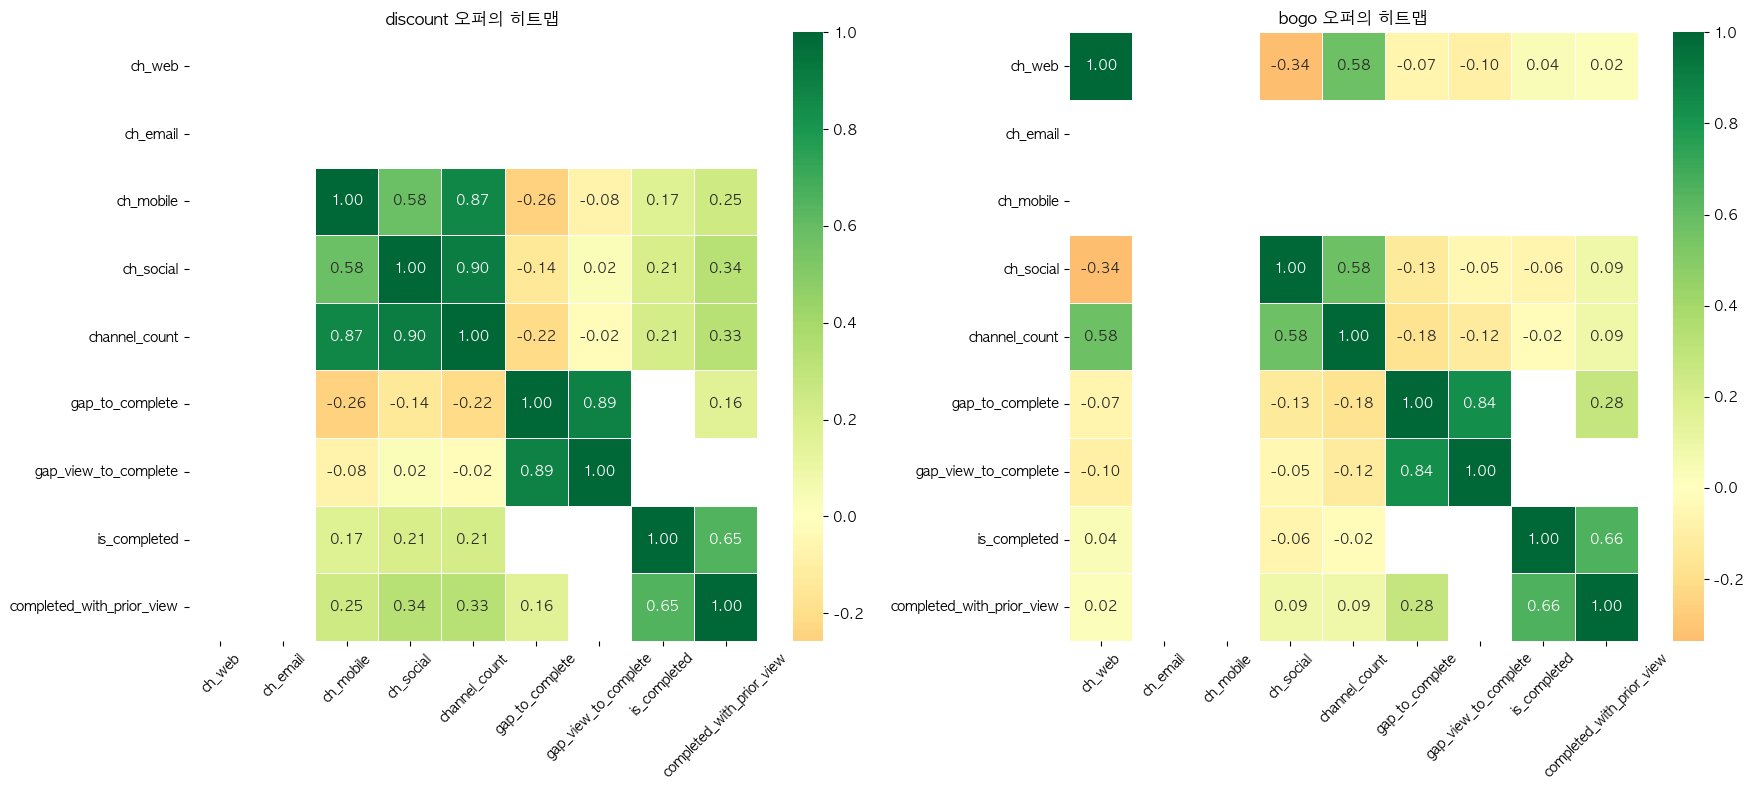

In [ ]:
# bogo, discount의 지표 히트맵 시각화
import seaborn as sns

discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [322]:
# discount 오퍼의 경우 소셜채널의 유무, 모바일채널의 유무, 채널 수가 완료율과 인지 후 완료율에 중간정도의 양의 상관관계를 가짐을 확인할 수 있다
# 하지만 bogo 오퍼의 경우 채널의 유무나 채널수가 완료율과 인지 후 완료율에 상관관계를 거의 가지지 않음을 확인할 수 있다

In [323]:
target_offers = ['bogo', 'discount']
target_channels = ['ch_web', 'ch_mobile', 'ch_social']

print("── 오퍼 타입별: 채널 유무에 따른 인지 후 완료율(aware_rate) 차이 검정 ──")
print("=" * 70)

for offer in target_offers:
    for ch in target_channels:
        # 1. 해당 오퍼 타입 데이터만 필터링
        temp_df = df[df['offer_type'] == offer]
        
        # 2. 교차표 생성 (채널 수 vs 인지 후 완료 여부)
        # aware_rate를 검정하기 위해 'completed_with_prior_view' 컬럼 사용
        ct = pd.crosstab(temp_df[ch], temp_df['completed_with_prior_view'])
        
        chi2(ct)

── 오퍼 타입별: 채널 유무에 따른 인지 후 완료율(aware_rate) 차이 검정 ──

p-value: 0.0005417027224483981
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.019807873246519832
효과크기 미미: 무시해도 될만한 연관성

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 3.1673728111143315e-54
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.08878764836211273
효과크기 미미: 무시해도 될만한 연관성

p-value: 1.0
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.24755038097601284
효과크기 작음: 체감도 낮은 연관성

p-value: 0.0
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.33663822967773466
효과크기 중간: 실무적으로 유의미한 연관성


In [324]:
### Bogo
# 웹 : 0.0284 : 효과크기 무시할 수준
# 소셜 : 0.0318 : 효과크기 무시할 수준
# 
### discount 
# 모바일 : 0.24373 : 효과크기 작음
# 소셜 : 0.3098 : 효과크기 중간
# 디스카운트 오퍼의 경우 

- 채널의 중복성: channel_count vs ch_social 
- informational 오퍼의 성공의 정의??
--> 직접적인 할인쿠폰이나 bogo 혜택은 없지만 신메뉴 출시 소식이나 브랜드 스토리를 전달함
--> complete가 목적이 아니기 때문에 is_viewed, gap_to_view가 핵심 지표가 됨
- gap to view가 짧다는 것은 마켓팅 메시지가 매력적인걸까 vs 해당 채널의 접근성이 좋다는걸까
- gap view to complete가 짧은 순으로 확인을 했더니 bogo 오퍼의 경우 오퍼를 확인하고 '완료'까지 하는데 시간이 덜 걸린다는 것을 확인하였다 전체 오퍼에서도 duration을 짧게 줄 수록 고민하는 시간이 줄고 오퍼 확인 후 완료까지 걸리는 시간이 짧아짐을 확인하였다 
--> bogo, discount의 view_to_comp, comp_rate, aware_rate에 관한 박스플랏 확인 후 통계검정

- view_rate -> 오퍼의 도달력
- aware_rate -> 오퍼의 설득력 (진짜 마케팅 효과) 
- gap_to_view -> 오퍼데 대한 반응 속도

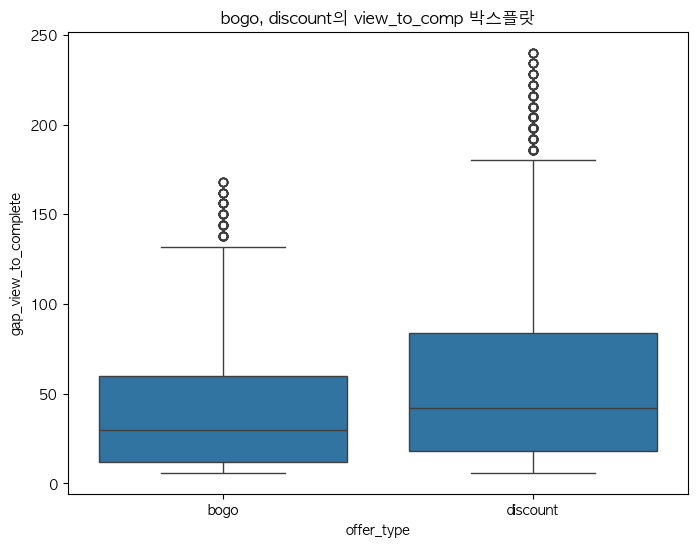

In [325]:
# bogo, discount의 view_to_comp 박스플랏 확인 후 통계검정
temp_df = df[(df['is_completed']==1) & (df['is_viewed']==1)]

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(data=temp_df, x='offer_type', y='gap_view_to_complete')
plt.title('bogo, discount의 view_to_comp 박스플랏')
plt.show() 

In [326]:
# bogo, discount의 comp_rate 박스플랏 확인 후 통계검정
temp_df = df.copy()

import seaborn as sns

contingency_table = pd.crosstab(temp_df['offer_type'], temp_df['is_completed'])
print("--- 교차표 (빈도수) ---")
display(contingency_table)

contingency_table = pd.crosstab(temp_df['offer_type'], temp_df['completed_with_prior_view'])
print("--- 교차표 (빈도수) ---")
display(contingency_table)

offer_type_df = df.groupby(['offer_type']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
offer_type_df.sort_values(by=['aware_rate'], ascending=[False]) 

--- 교차표 (빈도수) ---


is_completed,0,1
offer_type,,
bogo,14998,15501
discount,12943,17600
informational,15235,0


--- 교차표 (빈도수) ---


completed_with_prior_view,0,1
offer_type,,
bogo,21086,9413
discount,19408,11135
informational,15235,0


,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
1,discount,25.832007,71.402386,58.716480,11.759552,8.499362,0.699669,0.576237,0.364568,0.172675,30543
0,bogo,23.815842,49.562609,41.922873,7.500246,6.005607,0.827896,0.508246,0.308633,0.149513,30499
2,informational,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,0.000000,15235


In [327]:
# bogo, discount의 aware_rate 박스플랏 확인 후 통계검정

- view_rate을 계산할때는 전체 데이터 사용
- avg_gap_to comp, avg_view_to_comp, aware_rate을 계산할 때는 무조건 completed_without_prior_view==0인 데이터 사용

In [328]:
channel_offertype_df_rate = df[df['completed_without_prior_view']==0].groupby(['offer_type', 'channel_count']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_offertype_df_rate.sort_values(by=['avg_view_to_comp'], ascending=[False])

,offer_type,channel_count,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,count
2,discount,2.0,40.636025,100.984615,69.589154,20.000000,10.000000,0.427056,0.229885,0.215208,5655
4,discount,4.0,18.532290,70.024653,59.409861,8.505529,8.505529,0.979328,0.645031,0.580557,13835
3,discount,3.0,28.370412,66.533777,48.747614,10.000000,7.000000,0.612909,0.363731,0.326354,5779
0,bogo,3.0,25.936349,61.396331,46.641593,7.732727,7.000000,0.795614,0.387919,0.336616,12085
1,bogo,4.0,17.710617,46.607708,38.331525,7.537534,5.000000,0.966797,0.451350,0.385809,13854
5,informational,3.0,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,15235


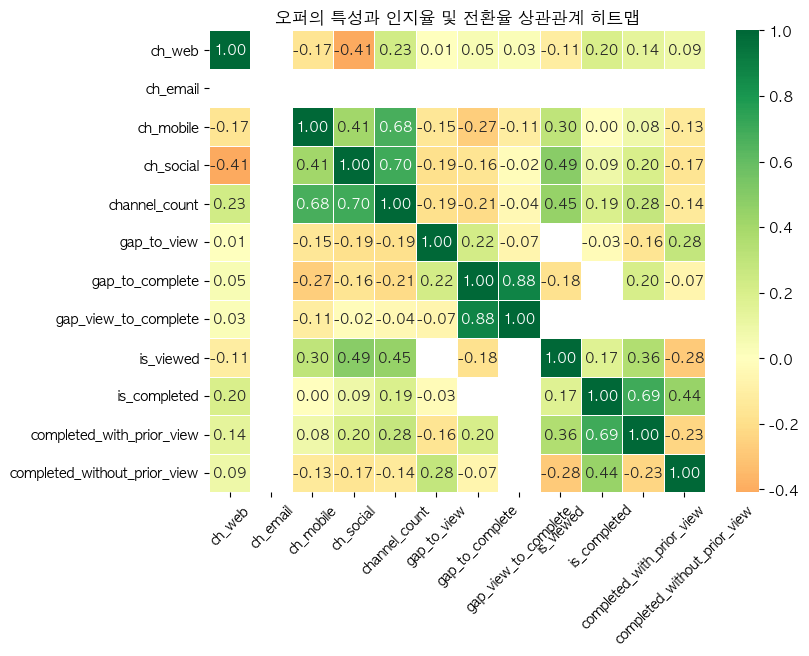

In [329]:
import seaborn as sns

ch_correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(ch_correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

In [330]:
discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

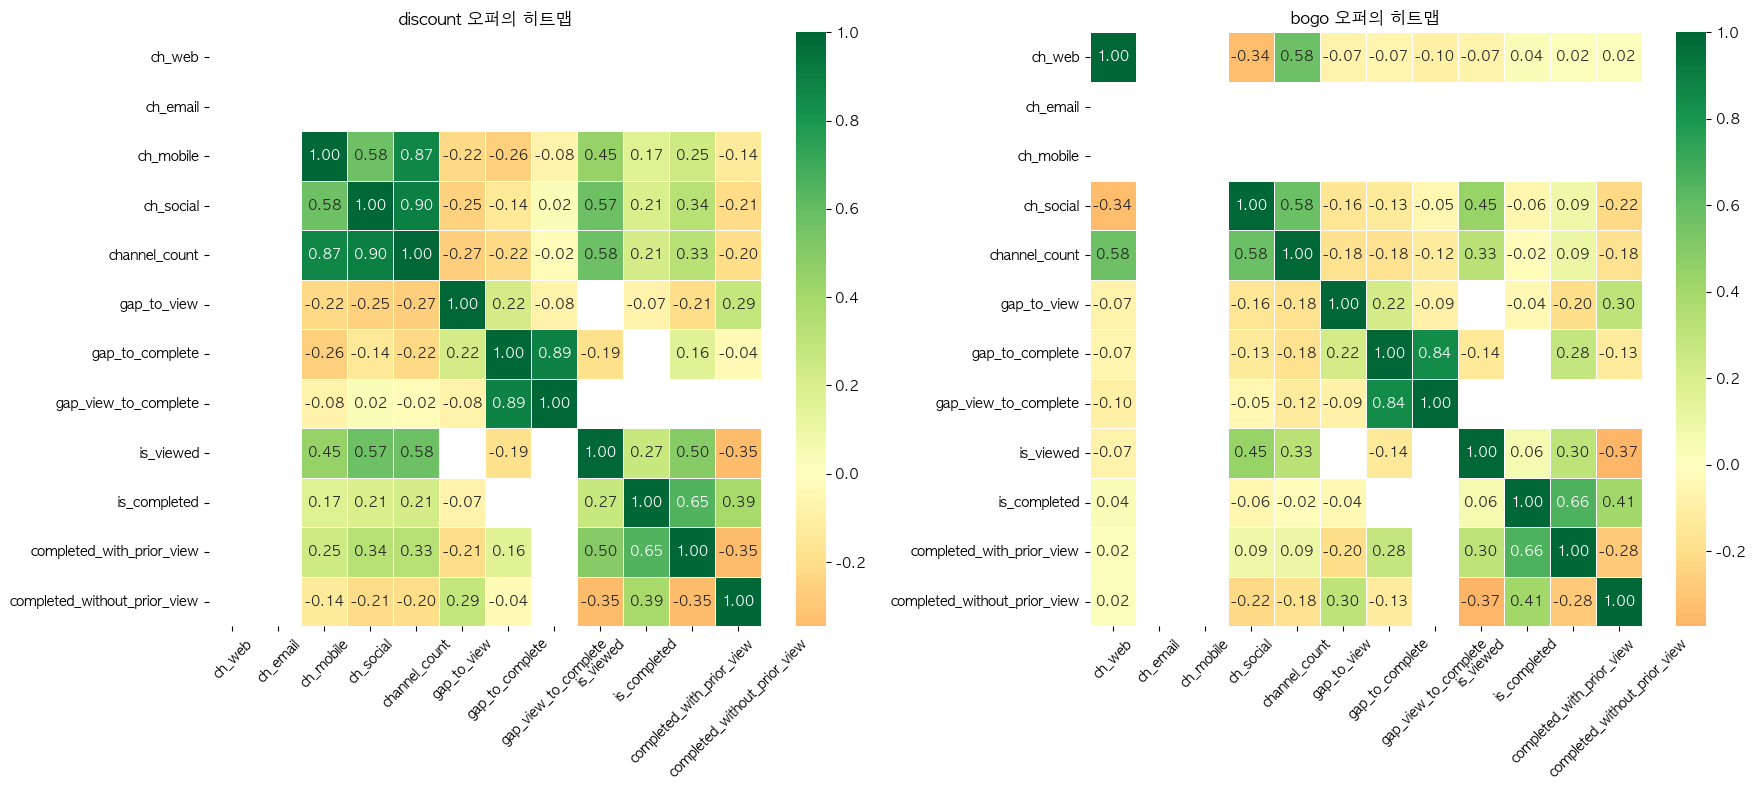

In [331]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [332]:
# 소셜 채널의 avg_gap_to_view 영향력에 대한 통계검정

In [333]:
df['view_count'].value_counts()

view_count
1.0    56567
Name: count, dtype: int64

In [334]:
df['complete_count'].value_counts() # 같은 오퍼에 대해서 같은 고객이 몇 번을 complete 했는지 카운트

complete_count
1.0    32624
2.0      476
3.0        1
Name: count, dtype: int64

In [335]:
df[df['complete_count']>1] # groupby

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
211,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,2,7.0,672.0,NaN,NaN,NaN,NaN,504.0,504.0,2.0,1.0,NaN,0.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,60대 이상,7.5-10만,2016,12,2016-12,0
426,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,504,bogo,2,5.0,624.0,NaN,NaN,NaN,NaN,510.0,510.0,2.0,1.0,NaN,6.0,0,1,1,NaN,10.0,10.0,1.0,1.0,1.0,1.0,4.0,F,50대,10만 이상,2015,11,2015-11,0
437,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,NaN,NaN,NaN,NaN,420.0,420.0,2.0,1.0,NaN,12.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,50대,7.5-10만,2016,8,2016-08,0
537,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,408,bogo,2,7.0,576.0,432.0,432.0,1.0,1.0,444.0,444.0,2.0,1.0,24.0,36.0,1,1,0,12.0,5.0,5.0,1.0,1.0,1.0,0.0,3.0,F,50대,5-7.5만,2017,4,2017-04,1
543,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,420.0,420.0,1.0,1.0,450.0,450.0,2.0,1.0,12.0,42.0,1,1,0,30.0,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,60대 이상,7.5-10만,2016,12,2016-12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75895,feb31e39c1e3407b9fdc7e79db9274b7,fafdcd668e3743c1bb461111dcafc2a4,504,discount,2,10.0,744.0,NaN,NaN,NaN,NaN,594.0,594.0,2.0,1.0,NaN,90.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,40대,5만 미만,2017,5,2017-05,0
76047,ff4bfebc3c92451aa546c7e100be0de4,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,2,7.0,672.0,NaN,NaN,NaN,NaN,504.0,504.0,2.0,1.0,NaN,0.0,0,1,1,NaN,5.0,5.0,1.0,1.0,1.0,0.0,3.0,M,40대,5만 미만,2016,5,2016-05,0
76078,ff6a080134fc44dc9c7e7b5abcfbe849,ae264e3637204a6fb9bb56bc8210ddfd,576,bogo,3,7.0,744.0,NaN,NaN,NaN,NaN,600.0,600.0,2.0,1.0,NaN,24.0,0,1,1,NaN,10.0,10.0,0.0,1.0,1.0,1.0,3.0,M,60대 이상,10만 이상,2017,12,2017-12,0
76115,ff80a43ecb34439491bd9ae1cff7c5fc,fafdcd668e3743c1bb461111dcafc2a4,408,discount,2,10.0,648.0,444.0,444.0,1.0,1.0,528.0,528.0,2.0,1.0,36.0,120.0,1,1,0,84.0,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,50대,5-7.5만,2014,2,2014-02,1


- 인지율 : 이벤트 인지를 한 채로 완료한 바람직한 경우 (t_viewed < t_completed)
- 비인지율 : 이벤트 인지를 하지도 않은 채로 우연히 완료한 경우 (마케팅 효과가 있다고 볼 수 없음)

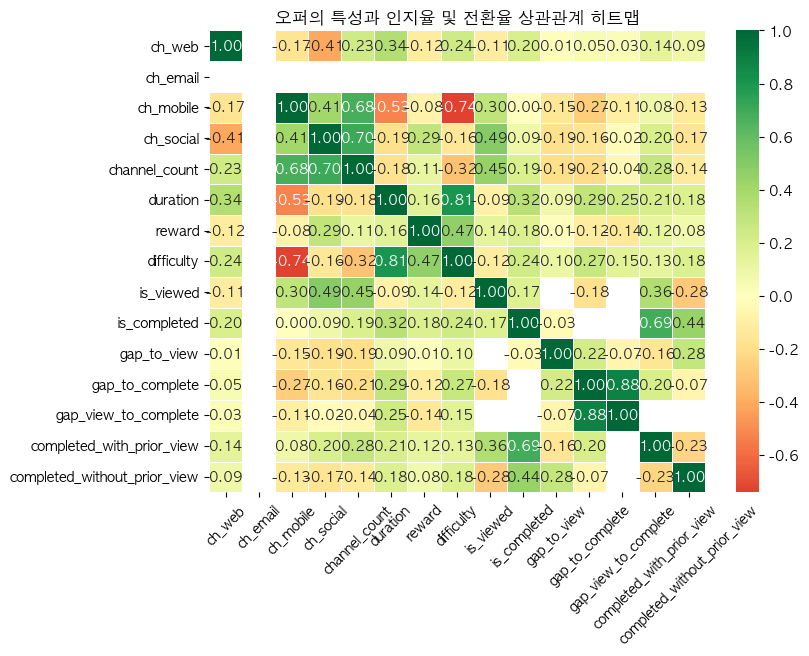

In [336]:
import seaborn as sns

correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 
                  'gap_to_view', 'gap_to_complete', 'gap_view_to_complete', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

In [337]:
discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

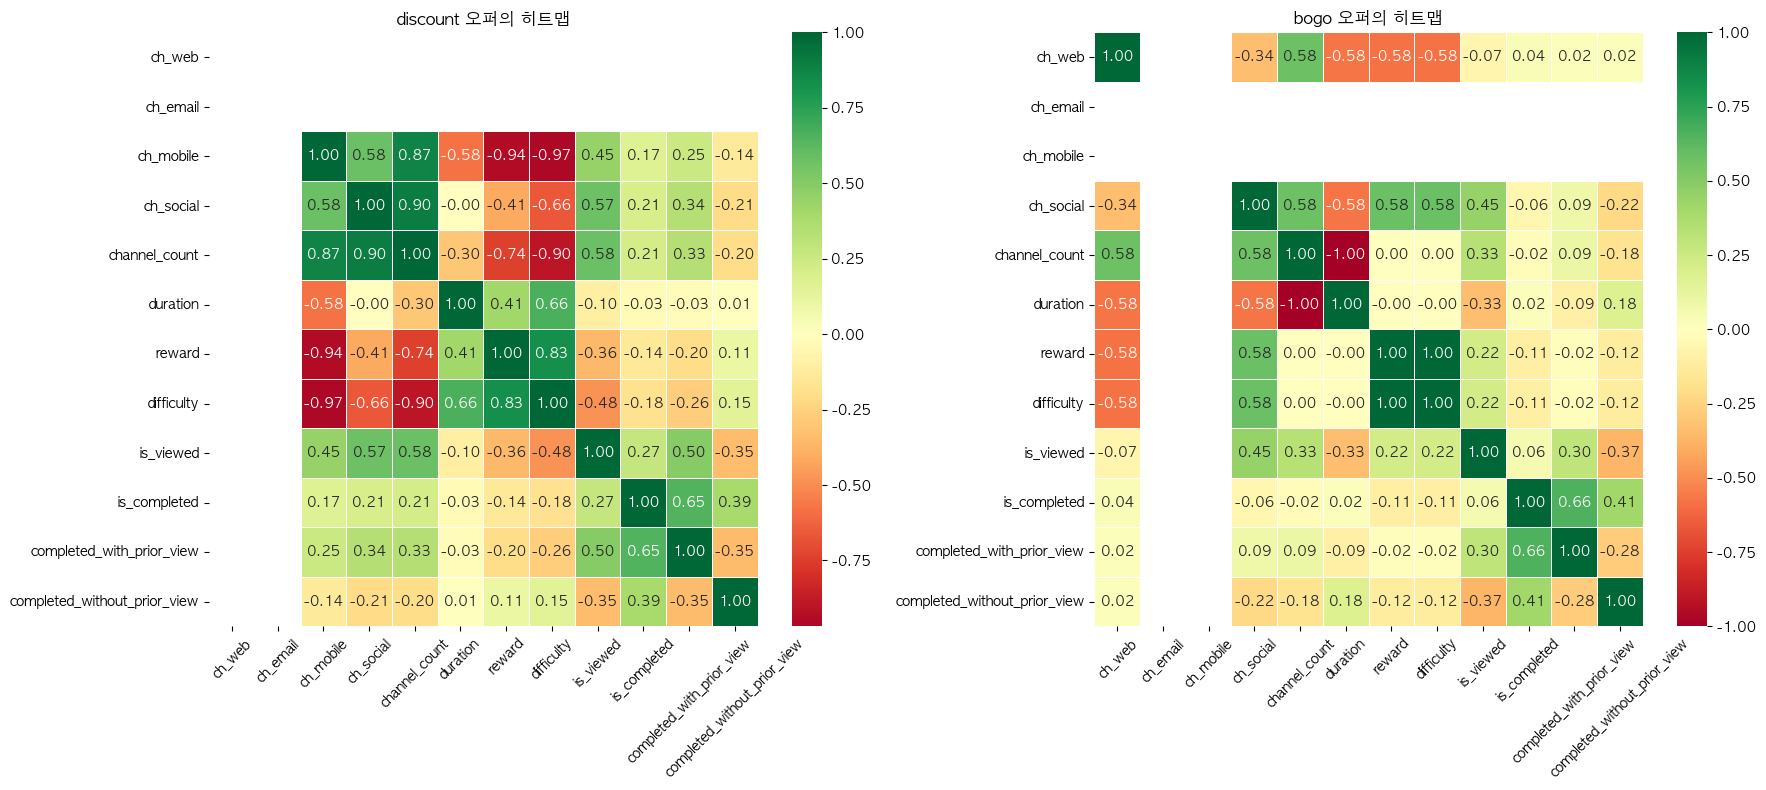

In [338]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [339]:
target_cols = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

offer_df_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty']).agg(
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
offer_df_rate.sort_values(by=['aware_rate', 'unaware_rate'], ascending=[False,True])

,offer_id,channel_count,offer_type,duration,reward,difficulty,view_rate,comp_rate,aware_rate,unaware_rate,count
9,fafdcd668e3743c1bb461111dcafc2a4,4.0,discount,10.0,2.0,10.0,0.964460,0.688430,0.546005,0.086087,7597
1,2298d6c36e964ae4a3e7e9706d1fb8c2,4.0,discount,7.0,3.0,7.0,0.958671,0.667277,0.507978,0.098614,7646
8,f19421c1d4aa40978ebb69ca19b0e20d,4.0,bogo,5.0,5.0,5.0,0.952054,0.562938,0.394928,0.098798,7571
4,4d5c57ea9a6940dd891ad53e9dbe8da0,4.0,bogo,5.0,10.0,10.0,0.952851,0.434743,0.310154,0.074016,7593
7,ae264e3637204a6fb9bb56bc8210ddfd,3.0,bogo,7.0,10.0,10.0,0.872160,0.474667,0.292766,0.137503,7658
2,2906b810c7d4411798c6938adc9daaa5,3.0,discount,7.0,2.0,10.0,0.532102,0.518213,0.247117,0.242794,7632
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,3.0,bogo,7.0,5.0,5.0,0.537710,0.560505,0.237853,0.286179,7677
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,2.0,discount,10.0,5.0,20.0,0.345853,0.432055,0.158712,0.262520,7668
3,3f207df678b143eea3cee63160fa8bed,3.0,informational,4.0,0.0,0.0,0.498622,0.000000,0.000000,0.000000,7617
5,5a8bc65990b245e5a138643cd4eb9837,3.0,informational,3.0,0.0,0.0,0.807167,0.000000,0.000000,0.000000,7618


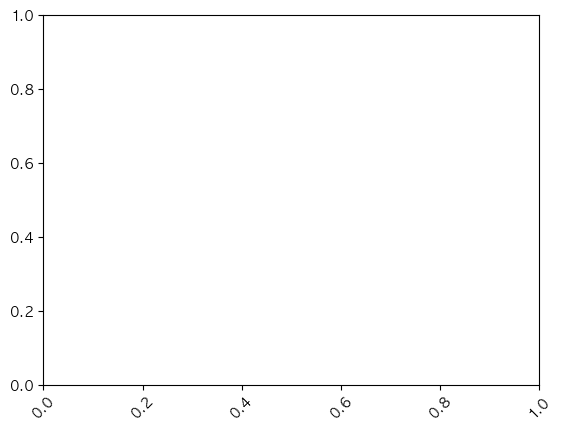

In [340]:
# 채널별 열람률, 완료율, 비인지율(완료는 했는데 이벤트 인지를 못하고 우연히 한 경우), 인지율(이벤트 인지한 채로 완료한 바람직한 경우) 확인
# 비율만 표시하면 공정한 결과가 아니므로, 각 그룹의 데이터 개수도 함께 표시
df[df['ch_web']==1]['is_viewed'].value_counts(normalize=True)

plt.xticks(rotation=45)
plt.show() 